<a href="https://colab.research.google.com/github/J4SIB/ai-course-gp/blob/main/numbers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

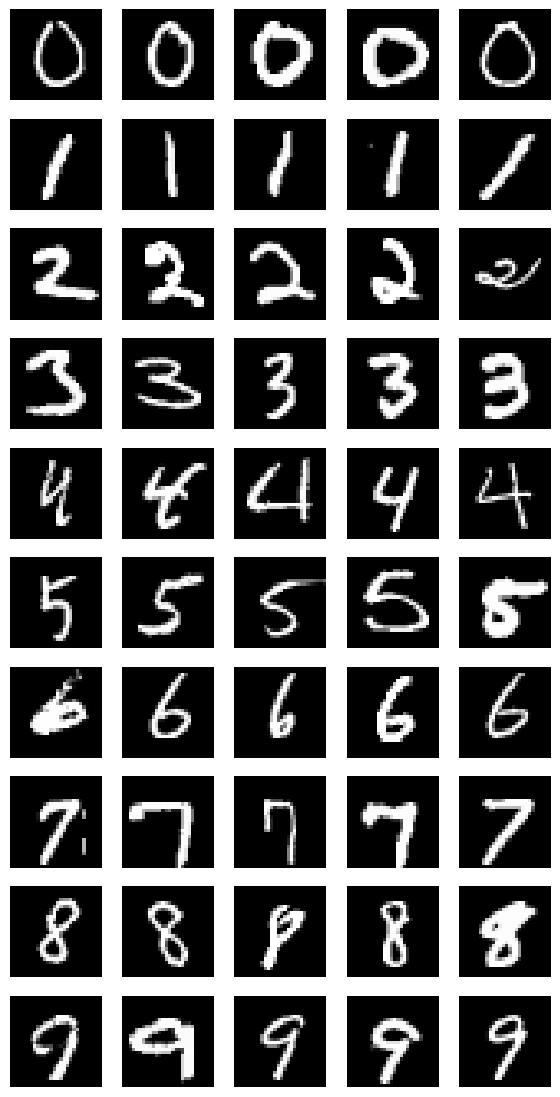

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

fig , axes = plt.subplots(nrows = 10, ncols=5, figsize=(7,14))
rng = np.random.default_rng()

for digit in range(10):
  idx = np.where(y_train == digit)[0]
  chosen = rng.choice(idx, size = 5, replace=False)

  for col, img_idx in enumerate(chosen):
    ax = axes[digit,col]
    ax.imshow(x_train[img_idx],cmap='gray')
    ax.axis("off")

plt.show()


In [ ]:
from tensorflow.keras.utils import to_categorical

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Po normalizacji: min/max x_train:", x_train.min(), x_train.max(), "dtype:", x_train.dtype)

x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

print("Po dodaniu kanału:", x_train.shape, x_test.shape)

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


Po normalizacji: min/max x_train: 0.0 1.0 dtype: float32
Po dodaniu kanału: (60000, 28, 28, 1) (10000, 28, 28, 1)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential

model = Sequential([
    layers.Flatten(input_shape=(28,28,1)),
    layers.Dense(512, activation="relu"),
    layers.Dense(256, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.compile(optimizer = "adam", loss="categorical_crossentropy", metrics=["accuracy"])

history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_split=0.1)


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.9026 - loss: 0.3286 - val_accuracy: 0.9710 - val_loss: 0.0885
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9740 - loss: 0.0803 - val_accuracy: 0.9758 - val_loss: 0.0837
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9833 - loss: 0.0528 - val_accuracy: 0.9763 - val_loss: 0.0770
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9867 - loss: 0.0395 - val_accuracy: 0.9800 - val_loss: 0.0700
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9902 - loss: 0.0288 - val_accuracy: 0.9782 - val_loss: 0.0898
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9911 - loss: 0.0252 - val_accuracy: 0.9812 - val_loss: 0.0723
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9934 - loss: 0.0192 - val_accuracy: 0.9825 - val_loss: 0.0807
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9934 -

In [ ]:

loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Strata: {loss:.4f}, Dokładność: {accuracy:.4f}")

Strata: 0.0881, Dokładność: 0.9801
